# MLOps Assignment 2 — Cats vs Dogs Model Development

| Field | Value |
|---|---|
| Programme | BITS Pilani WILP M.Tech. Artificial Intelligence and Machine Learning |
| Course | MLOps (S2-25 AIMLCZG523) |
| Assignment | Assignment 2 |
| Student name | **[ENTER NAME]** |
| Student ID | **[ENTER BITS ID]** |
| Submission date | **[ENTER DATE]** |
| Repository component | Reproducible model-development experiment |

> **Execution contract:** this notebook defaults to `RUN_TRAINING = False` so it can be
> validated without downloading a dataset or spending several minutes training. The dry
> run checks configuration, preprocessing, tensor shapes, model construction, and artifact
> discovery. Set `RUN_TRAINING = True` after `dvc repro prepare` (or `dvc repro`) to create
> genuine metrics, plots, a checkpoint, and an MLflow run. Never report dry-run outputs as
> trained-model performance.

## 1. Problem understanding and objective

The model-development part of this assignment builds a reproducible binary image
classifier for **cats** and **dogs**. It is deliberately connected to the repository's
production pipeline instead of being a disconnected exploratory notebook:

1. dataset acquisition and provenance are controlled by DVC;
2. preprocessing is shared between training and online inference;
3. a compact convolutional neural network (CNN) produces two class logits;
4. the training script records parameters, metrics, plots, and the model in MLflow;
5. the serialized checkpoint is the contract consumed by the prediction API.

This notebook is therefore both a tutorial and an auditable experiment companion. The
canonical automation remains `dvc repro`; notebook execution is intended for inspection,
teaching, and submission evidence.

### Success criteria

- The processed train, validation, and test partitions have the same label mapping.
- No source path or processed-image content hash appears in more than one split.
- Preprocessing yields an RGB tensor shaped `(3, 224, 224)`.
- The CNN maps a batch shaped `(N, 3, 224, 224)` to logits shaped `(N, 2)`.
- A full run writes test metrics, diagnostic plots, model metadata, a checkpoint, and an
  MLflow run ID.

## 2. Theory and mathematical background

### Intuition

Early convolutional layers learn local edges and textures; deeper layers combine them into
shapes useful for distinguishing cats from dogs. Max pooling reduces spatial resolution,
while adaptive average pooling converts each learned feature map into one value. A linear
layer then returns one score (logit) per class.

### Formal model

For input image tensor $x$, a convolutional layer computes feature map $k$ as

$$z_k = \sigma\left(\mathrm{BN}\left(W_k * x + b_k\right)\right),$$

where $*$ is convolution, BN is batch normalization, and $\sigma$ is ReLU. The final logits
$\mathbf{z}=[z_{cat},z_{dog}]$ become probabilities through softmax:

$$p(y=c\mid x)=\frac{e^{z_c}}{\sum_j e^{z_j}}.$$

Training minimizes multiclass cross-entropy for the true class $y$:

$$\mathcal{L}(x,y)=-\log p(y\mid x).$$

The implementation returns **raw logits** because `CrossEntropyLoss` combines log-softmax
and negative log likelihood in a numerically stable operation.

### MLOps relevance

A useful model is more than its weights. Reproducibility requires the data fingerprint,
label ordering, preprocessing constants, code revision, hyperparameters, evaluation
evidence, and model checksum to travel with the experiment and deployment artifact.

## 3. Environment setup

The imports below are explicit so the notebook can run top-to-bottom in the project virtual
environment. Standard-library modules handle paths and artifact inspection; NumPy/Pillow
support image demonstration; PyTorch/torchvision provide the model pipeline; MLflow reads
tracked experiments; Matplotlib renders bounded evidence.

In [1]:
import csv
import json
import os
import random
import subprocess
import sys
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import torch
import yaml
from PIL import Image

# MLflow >=3.x refuses the filesystem tracking backend ("file:./mlruns")
# by default now that it's in maintenance mode upstream. This project's
# run history and submitted evidence are tied to that file-based
# mlruns/ directory, so opt back in rather than migrating backends.
os.environ.setdefault("MLFLOW_ALLOW_FILE_STORE", "true")

print(f"Python: {sys.version.split()[0]}")
print(f"PyTorch: {torch.__version__}")
print(f"MLflow: {mlflow.__version__}")

Python: 3.14.6
PyTorch: 2.13.0+cu132
MLflow: 3.15.1


### 3.1 Locate the repository

**Theory/purpose.** Notebook working directories vary between JupyterLab, VS Code, and
`nbconvert`. The helper walks upward until it finds both `pyproject.toml` and the source
package. Its input is a starting directory and its output is the repository root; failure is
explicit rather than silently importing a different package.

In [2]:
def find_project_root(start_directory: Path) -> Path:
    """Find the nearest Cats-vs-Dogs project root.

    Args:
        start_directory: Directory from which to begin the upward search.

    Returns:
        Path: Directory containing ``pyproject.toml`` and ``src/cats_dogs_mlops``.

    Raises:
        FileNotFoundError: If the notebook is executed outside the project tree.
    """

    resolved_start = start_directory.resolve()
    for candidate in (resolved_start, *resolved_start.parents):
        package_dir = candidate / "src" / "cats_dogs_mlops"
        if (candidate / "pyproject.toml").is_file() and package_dir.is_dir():
            return candidate
    raise FileNotFoundError(
        "Could not locate the project root. Start Jupyter inside the repository."
    )


PROJECT_ROOT = find_project_root(Path.cwd())
os.chdir(PROJECT_ROOT)
source_directory = str(PROJECT_ROOT / "src")
if source_directory not in sys.path:
    sys.path.insert(0, source_directory)

print(f"Project root: {PROJECT_ROOT}")

Project root: D:\PostGraduationProjects\MLOps-Cats-Dogs-Pipeline


### 3.2 Reproducibility and run controls

`RUN_TRAINING=False` is the safe submission default. `QUICK_MODE=True` limits an explicitly
enabled trial to one epoch; change it to `False` for the five-epoch configuration recorded
in `params.yaml`. A fixed seed reduces variation from Python, NumPy, and PyTorch random
number generators. Full bitwise reproducibility can still depend on hardware and library
versions.

In [3]:
RUN_TRAINING = True
QUICK_MODE = False
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

execution_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training enabled: {RUN_TRAINING}")
print(f"Quick mode: {QUICK_MODE}")
print(f"Available device: {execution_device}")

Training enabled: True
Quick mode: False
Available device: cuda


## 4. Configuration and data provenance

`params.yaml` is the human-readable parameter source used by DVC. The raw-data provenance
record is created by `scripts/download_data.py`; it identifies the public Kaggle handle and
download time without embedding the images in Git. The processed manifest adds the source
path, assigned split, label, dimensions, and SHA-256 content fingerprint for every retained
image.

In [4]:
params_path = PROJECT_ROOT / "params.yaml"
with params_path.open("r", encoding="utf-8") as params_file:
    parameters = yaml.safe_load(params_file)

data_parameters = parameters["data"]
training_parameters = parameters["training"]
tracking_parameters = parameters["tracking"]

RAW_DATA_DIR = PROJECT_ROOT / data_parameters["raw_dir"]
PROCESSED_DATA_DIR = PROJECT_ROOT / data_parameters["processed_dir"]
MANIFEST_PATH = PROCESSED_DATA_DIR / "manifest.csv"
PROVENANCE_PATH = RAW_DATA_DIR / "dataset_provenance.json"
IMAGE_SIZE = int(data_parameters["image_size"])

print(json.dumps(parameters, indent=2))

{
  "data": {
    "dataset_handle": "tongpython/cat-and-dog",
    "raw_dir": "data/raw",
    "processed_dir": "data/processed",
    "image_size": 224,
    "train_ratio": 0.8,
    "validation_ratio": 0.1,
    "test_ratio": 0.1,
    "max_images_per_class": 1000,
    "seed": 42
  },
  "training": {
    "batch_size": 32,
    "epochs": 5,
    "learning_rate": 0.001,
    "weight_decay": 0.0001,
    "num_workers": 0,
    "model_version": "1.0.0"
  },
  "tracking": {
    "uri": "file:./mlruns",
    "experiment_name": "cats-vs-dogs-baseline"
  }
}


### 4.1 Inspect provenance without assuming the dataset is present

The cell reports either the actual generated provenance record or the expected public source
declared in configuration. This distinction prevents a missing download from being mistaken
for verified data lineage.

In [5]:
if PROVENANCE_PATH.is_file():
    provenance = json.loads(PROVENANCE_PATH.read_text(encoding="utf-8"))
    provenance_status = "verified from generated provenance file"
else:
    provenance = {
        "dataset_handle": data_parameters["dataset_handle"],
        "downloaded_at_utc": None,
    }
    provenance_status = "configured source only; raw data has not been downloaded"

print(f"Provenance status: {provenance_status}")
print(json.dumps(provenance, indent=2))

Provenance status: verified from generated provenance file
{
  "dataset_handle": "tongpython/cat-and-dog",
  "downloaded_at_utc": "2026-08-11T09:10:57.137096+00:00",
  "kagglehub_cache_path": "C:\\Users\\hamza\\.cache\\kagglehub\\datasets\\tongpython\\cat-and-dog\\versions\\1"
}


## 5. Dataset and split integrity checks

**Theory/purpose.** Evaluation is credible only when examples do not leak across training,
validation, and test sets. The helper reads the manifest, verifies its schema, counts each
`(split, label)` group, and checks two leakage signals:

- the same original source path assigned to multiple splits;
- identical processed content hashes assigned to multiple splits.

**Input:** `manifest.csv`. **Output:** a compact audit dictionary. The function returns a
clear `available=False` result when preprocessing has not yet run, allowing dry validation.

In [6]:
def audit_split_manifest(manifest_path: Path) -> dict[str, object]:
    """Audit processed-data balance, schema, dimensions, and split leakage.

    Args:
        manifest_path: CSV produced by ``scripts/prepare_data.py``.

    Returns:
        dict[str, object]: Availability, row/group counts, shape checks, and leakage counts.

    Raises:
        ValueError: If a present manifest omits required columns or contains an unknown split.
    """

    if not manifest_path.is_file():
        return {
            "available": False,
            "message": "Run `dvc repro prepare` to create the processed manifest.",
        }

    with manifest_path.open("r", newline="", encoding="utf-8") as manifest_file:
        rows = list(csv.DictReader(manifest_file))

    required_columns = {
        "split",
        "label",
        "source_relative_path",
        "processed_relative_path",
        "sha256",
        "width",
        "height",
    }
    present_columns = set(rows[0]) if rows else set()
    missing_columns = required_columns.difference(present_columns)
    if missing_columns:
        raise ValueError(f"Manifest columns missing: {sorted(missing_columns)}")

    expected_splits = {"train", "validation", "test"}
    observed_splits = {row["split"] for row in rows}
    unknown_splits = observed_splits.difference(expected_splits)
    if unknown_splits:
        raise ValueError(f"Unknown manifest splits: {sorted(unknown_splits)}")

    group_counts = Counter((row["split"], row["label"]) for row in rows)
    source_splits: dict[str, set[str]] = defaultdict(set)
    hash_splits: dict[str, set[str]] = defaultdict(set)
    for row in rows:
        source_splits[row["source_relative_path"]].add(row["split"])
        hash_splits[row["sha256"]].add(row["split"])

    source_leakage = sum(len(splits) > 1 for splits in source_splits.values())
    content_leakage = sum(len(splits) > 1 for splits in hash_splits.values())
    correct_dimensions = all(
        int(row["width"]) == IMAGE_SIZE and int(row["height"]) == IMAGE_SIZE
        for row in rows
    )
    return {
        "available": True,
        "row_count": len(rows),
        "counts": {
            f"{split}/{label}": group_counts[(split, label)]
            for split in ("train", "validation", "test")
            for label in ("cats", "dogs")
        },
        "labels": sorted({row["label"] for row in rows}),
        "all_dimensions_match": correct_dimensions,
        "source_paths_crossing_splits": source_leakage,
        "content_hashes_crossing_splits": content_leakage,
    }


split_audit = audit_split_manifest(MANIFEST_PATH)
print(json.dumps(split_audit, indent=2))

if split_audit["available"]:
    assert split_audit["labels"] == ["cats", "dogs"]
    assert split_audit["all_dimensions_match"]
    assert split_audit["source_paths_crossing_splits"] == 0
    assert split_audit["content_hashes_crossing_splits"] == 0

{
  "available": true,
  "row_count": 2000,
  "counts": {
    "train/cats": 800,
    "train/dogs": 800,
    "validation/cats": 100,
    "validation/dogs": 100,
    "test/cats": 100,
    "test/dogs": 100
  },
  "labels": [
    "cats",
    "dogs"
  ],
  "all_dimensions_match": true,
  "source_paths_crossing_splits": 0,
  "content_hashes_crossing_splits": 0
}


### 5.1 Verify the on-disk ImageFolder contract

PyTorch's `ImageFolder` assigns class indices alphabetically. The deployed checkpoint stores
this ordering, so every split must contain the same class directories. The following bounded
inventory verifies directory presence and file counts without decoding the whole dataset.

In [7]:
expected_splits = ("train", "validation", "test")
expected_classes = ("cats", "dogs")
split_inventory: dict[str, dict[str, int | None]] = {}

for split_name in expected_splits:
    split_inventory[split_name] = {}
    for class_name in expected_classes:
        class_directory = PROCESSED_DATA_DIR / split_name / class_name
        image_count = (
            sum(path.is_file() for path in class_directory.iterdir())
            if class_directory.is_dir()
            else None
        )
        split_inventory[split_name][class_name] = image_count

data_ready = all(
    count is not None and count > 0
    for class_counts in split_inventory.values()
    for count in class_counts.values()
)
print(json.dumps(split_inventory, indent=2))
print(f"All required split/class directories are ready: {data_ready}")

{
  "train": {
    "cats": 800,
    "dogs": 800
  },
  "validation": {
    "cats": 100,
    "dogs": 100
  },
  "test": {
    "cats": 100,
    "dogs": 100
  }
}
All required split/class directories are ready: True


## 6. Preprocessing demonstration

Training uses random crop, horizontal flip, and mild colour jitter for regularization.
Validation, testing, and serving use deterministic resize and normalization. For channel
value $x\in[0,1]$, normalization is

$$x' = \frac{x-\mu}{\sigma}, \qquad \mu=\sigma=0.5,$$

which maps the nominal range to $[-1,1]$. If processed data is absent, this section creates
a labelled synthetic colour pattern **only to test the transform contract**; it is not a
training example or evidence of predictive quality.

In [8]:
from cats_dogs_mlops.config import (
    CLASS_NAMES,
    NORMALIZATION_MEAN,
    NORMALIZATION_STD,
)
from cats_dogs_mlops.preprocessing import (
    build_evaluation_transform,
    build_training_transform,
    canonicalize_image,
)

real_sample_path = next(
    (path for path in (PROCESSED_DATA_DIR / "train").glob("*/*") if path.is_file()),
    None,
)
if real_sample_path is not None:
    with Image.open(real_sample_path) as opened_image:
        source_image = opened_image.convert("RGB").copy()
    sample_description = f"processed dataset sample: {real_sample_path.relative_to(PROJECT_ROOT)}"
else:
    horizontal = np.linspace(0, 255, IMAGE_SIZE, dtype=np.uint8)
    vertical = np.linspace(255, 0, IMAGE_SIZE, dtype=np.uint8)
    red_channel = np.tile(horizontal, (IMAGE_SIZE, 1))
    green_channel = np.tile(vertical[:, None], (1, IMAGE_SIZE))
    blue_channel = np.full((IMAGE_SIZE, IMAGE_SIZE), 128, dtype=np.uint8)
    source_image = Image.fromarray(
        np.stack([red_channel, green_channel, blue_channel], axis=-1),
        mode="RGB",
    )
    sample_description = "synthetic transform-contract pattern (not training data)"

canonical_image = canonicalize_image(source_image, IMAGE_SIZE)
evaluation_tensor = build_evaluation_transform(IMAGE_SIZE)(canonical_image)
assert evaluation_tensor.shape == (3, IMAGE_SIZE, IMAGE_SIZE)
assert evaluation_tensor.dtype == torch.float32

print(f"Sample: {sample_description}")
print(f"Canonical image mode/size: {canonical_image.mode} / {canonical_image.size}")
print(f"Evaluation tensor shape: {tuple(evaluation_tensor.shape)}")
print(
    f"Normalized range: [{evaluation_tensor.min().item():.3f}, "
    f"{evaluation_tensor.max().item():.3f}]"
)

Sample: processed dataset sample: data\processed\train\cats\cats_00000.jpg
Canonical image mode/size: RGB / (224, 224)
Evaluation tensor shape: (3, 224, 224)
Normalized range: [-1.000, 1.000]


### 6.1 Visualize deterministic and augmented views

The normalized tensors are reversed to display RGB values. Two stochastic training views
demonstrate why augmentation exposes the model to plausible variations while the evaluation
path remains deterministic.

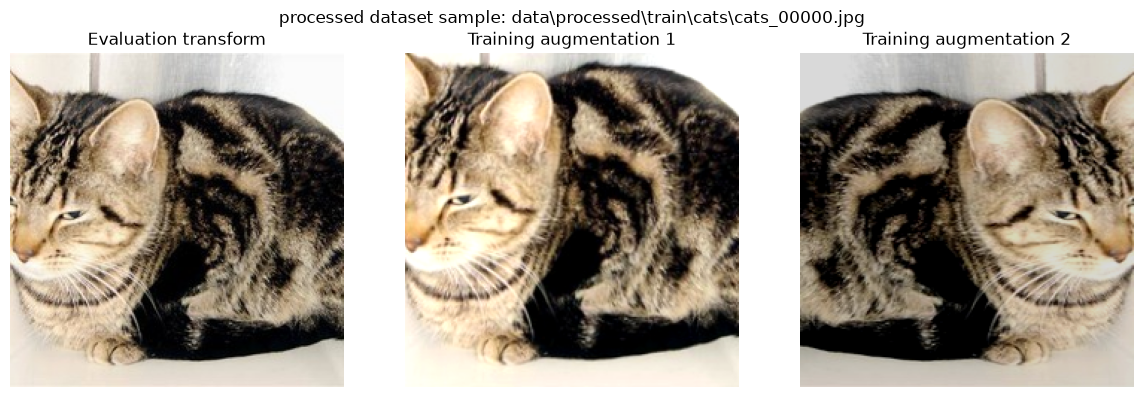

In [9]:
channel_mean = torch.tensor(NORMALIZATION_MEAN).view(3, 1, 1)
channel_std = torch.tensor(NORMALIZATION_STD).view(3, 1, 1)
training_transform = build_training_transform(IMAGE_SIZE)

display_tensors = [
    evaluation_tensor,
    training_transform(canonical_image),
    training_transform(canonical_image),
]
display_titles = ["Evaluation transform", "Training augmentation 1", "Training augmentation 2"]

figure, axes = plt.subplots(1, 3, figsize=(12, 4))
for axis, image_tensor, title in zip(axes, display_tensors, display_titles):
    display_array = (
        (image_tensor * channel_std + channel_mean)
        .clamp(0, 1)
        .permute(1, 2, 0)
        .numpy()
    )
    axis.imshow(display_array)
    axis.set_title(title)
    axis.axis("off")
figure.suptitle(sample_description)
figure.tight_layout()
plt.show()

## 7. Model architecture and output-shape check

**Theory/purpose.** `CatDogCNN` contains three convolutional blocks followed by adaptive
average pooling, dropout, and a two-unit linear classifier. The output is `(batch, classes)`.
This dry forward pass catches channel, shape, and class-count mismatches before costly
training. The input is random and the weights are untrained; probabilities are therefore not
predictions to interpret.

In [10]:
from cats_dogs_mlops.model import create_model

model = create_model(num_classes=len(CLASS_NAMES)).to(execution_device)
model.eval()
dummy_batch = torch.zeros((2, 3, IMAGE_SIZE, IMAGE_SIZE), device=execution_device)

with torch.inference_mode():
    dummy_logits = model(dummy_batch)
    dummy_probabilities = torch.softmax(dummy_logits, dim=1)

trainable_parameters = sum(
    parameter.numel() for parameter in model.parameters() if parameter.requires_grad
)
assert dummy_logits.shape == (2, len(CLASS_NAMES))
assert torch.allclose(
    dummy_probabilities.sum(dim=1),
    torch.ones(2, device=execution_device),
    atol=1e-6,
)

print(model)
print(f"Trainable parameters: {trainable_parameters:,}")
print(f"Input shape: {tuple(dummy_batch.shape)}")
print(f"Output logits shape: {tuple(dummy_logits.shape)}")
print("Dry-run softmax row sums:", dummy_probabilities.sum(dim=1).cpu().tolist())

CatDogCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(st

## 8. Tracked training invocation

The repository training script is the single implementation of optimization and evaluation.
It uses AdamW, cross-entropy loss, sample-weighted epoch metrics, a held-out test set, and
MLflow logging. Invoking it as a subprocess keeps the notebook faithful to the same command
used by DVC and CI.

- **Quick mode:** one epoch for a bounded pipeline check.
- **Full mode:** the configured epoch count for submission evidence.
- **Input:** processed `ImageFolder` tree.
- **Output:** checkpoint, metrics JSON, plots, metadata JSON, and MLflow run.

In [11]:
configured_epochs = int(training_parameters["epochs"])
selected_epochs = 1 if QUICK_MODE else configured_epochs
training_command = [
    sys.executable,
    "scripts/train.py",
    "--data-dir",
    str(PROCESSED_DATA_DIR),
    "--model-path",
    "models/cat_dog_cnn.pt",
    "--metrics-path",
    "metrics/training_metrics.json",
    "--artifacts-dir",
    "artifacts",
    "--image-size",
    str(IMAGE_SIZE),
    "--epochs",
    str(selected_epochs),
    "--batch-size",
    str(training_parameters["batch_size"]),
    "--learning-rate",
    str(training_parameters["learning_rate"]),
    "--weight-decay",
    str(training_parameters["weight_decay"]),
    "--num-workers",
    str(training_parameters["num_workers"]),
    "--seed",
    str(data_parameters["seed"]),
    "--model-version",
    str(training_parameters["model_version"]),
    "--tracking-uri",
    str(tracking_parameters["uri"]),
    "--experiment-name",
    str(tracking_parameters["experiment_name"]),
]

print("Training command:")
print(subprocess.list2cmdline(training_command))

if RUN_TRAINING:
    if not data_ready:
        raise RuntimeError(
            "Training was requested, but processed split folders are unavailable. "
            "Run `dvc repro prepare` first."
        )
    completed_training = subprocess.run(
        training_command,
        cwd=PROJECT_ROOT,
        check=True,
        text=True,
    )
    print(f"Training process exit code: {completed_training.returncode}")
else:
    print(
        "Training skipped by design. Set RUN_TRAINING=True after preparing the data; "
        "set QUICK_MODE=False for the configured full run."
    )

Training command:
C:\Users\hamza\.virtualenvs\MLOps-Cats-Dogs-Pipeline-qxGGk82j\Scripts\python.exe scripts/train.py --data-dir D:\PostGraduationProjects\MLOps-Cats-Dogs-Pipeline\data\processed --model-path models/cat_dog_cnn.pt --metrics-path metrics/training_metrics.json --artifacts-dir artifacts --image-size 224 --epochs 5 --batch-size 32 --learning-rate 0.001 --weight-decay 0.0001 --num-workers 0 --seed 42 --model-version 1.0.0 --tracking-uri file:./mlruns --experiment-name cats-vs-dogs-baseline
Training process exit code: 0


## 9. Artifact and MLflow inspection

A deployable experiment must leave traceable evidence. This section checks expected artifact
locations and, when a local MLflow store already exists, displays the five most recent runs
for the configured experiment. It does not create an empty tracking store during dry mode.

In [12]:
expected_artifacts = {
    "checkpoint": PROJECT_ROOT / "models" / "cat_dog_cnn.pt",
    "metrics": PROJECT_ROOT / "metrics" / "training_metrics.json",
    "learning_curves": PROJECT_ROOT / "artifacts" / "loss_curves.png",
    "confusion_matrix": PROJECT_ROOT / "artifacts" / "confusion_matrix.png",
    "model_metadata": PROJECT_ROOT / "artifacts" / "model_metadata.json",
}

artifact_inventory = {
    name: {
        "path": str(path.relative_to(PROJECT_ROOT)),
        "exists": path.is_file(),
        "size_bytes": path.stat().st_size if path.is_file() else None,
    }
    for name, path in expected_artifacts.items()
}
print(json.dumps(artifact_inventory, indent=2))

{
  "checkpoint": {
    "path": "models\\cat_dog_cnn.pt",
    "exists": true,
    "size_bytes": 386322
  },
  "metrics": {
    "path": "metrics\\training_metrics.json",
    "exists": true,
    "size_bytes": 1095
  },
  "learning_curves": {
    "path": "artifacts\\loss_curves.png",
    "exists": true,
    "size_bytes": 87762
  },
  "confusion_matrix": {
    "path": "artifacts\\confusion_matrix.png",
    "exists": true,
    "size_bytes": 30154
  },
  "model_metadata": {
    "path": "artifacts\\model_metadata.json",
    "exists": true,
    "size_bytes": 533
  }
}


### 9.1 Read recent MLflow runs

MLflow binds parameters, time-stepped training metrics, final test metrics, Git revision,
model version, and artifacts to a run ID. The guarded query below is read-only when the
local tracking directory exists and remains executable before any experiment has run.

In [13]:
mlruns_directory = PROJECT_ROOT / "mlruns"
if mlruns_directory.is_dir():
    mlflow.set_tracking_uri(mlruns_directory.resolve().as_uri())
    experiment = mlflow.get_experiment_by_name(tracking_parameters["experiment_name"])
    if experiment is None:
        print("MLflow store exists, but the configured experiment has no runs yet.")
    else:
        recent_runs = mlflow.search_runs(
            experiment_ids=[experiment.experiment_id],
            max_results=5,
            order_by=["attributes.start_time DESC"],
        )
        visible_columns = [
            column
            for column in (
                "run_id",
                "status",
                "params.model_version",
                "params.epochs",
                "metrics.test_accuracy",
                "metrics.test_f1_weighted",
                "metrics.training_duration_seconds",
            )
            if column in recent_runs.columns
        ]
        print(recent_runs[visible_columns].to_string(index=False))
else:
    print("No local MLflow store yet. A full training run will create `mlruns/`.")

                          run_id   status params.epochs  metrics.test_accuracy  metrics.test_f1_weighted  metrics.training_duration_seconds
ee54aa79d62b41c9a1104dc9103c562a FINISHED             5                  0.620                  0.604167                          65.371398
4045b2ae755640799354dab50621441b FINISHED             5                  0.595                  0.566833                         304.868336


## 10. Evaluation and diagnostic plots

For $N$ test examples, accuracy is $\frac{\text{correct}}{N}$. Per-class precision and
recall are

$$\mathrm{Precision}=\frac{TP}{TP+FP}, \qquad
\mathrm{Recall}=\frac{TP}{TP+FN},$$

and $F_1=2\frac{PR}{P+R}$. The training script reports weighted precision, recall, and
$F_1$ so each class contributes in proportion to its test support. Accuracy summarizes
overall correctness; the confusion matrix reveals which class is confused with the other;
learning curves reveal underfitting or widening train–validation gaps.

The cell below displays only genuine artifacts already generated by the training pipeline.
It intentionally does not fabricate plots when they are absent.

{
  "test_accuracy": 0.62,
  "test_precision_weighted": 0.6428571428571429,
  "test_recall_weighted": 0.62,
  "test_f1_weighted": 0.6041666666666666,
  "training_duration_seconds": 65.37139800000296,
  "model_version": "1.0.0",
  "model_sha256": "8070fc046c4e247d30fa0ec469cd2fd22c1205070c9ddde4121ba540bcc0a793",
  "mlflow_run_id": "ee54aa79d62b41c9a1104dc9103c562a",
  "device": "cuda",
  "git_commit": "bc52b5fc9b19fad982244250569c17660926118d"
}


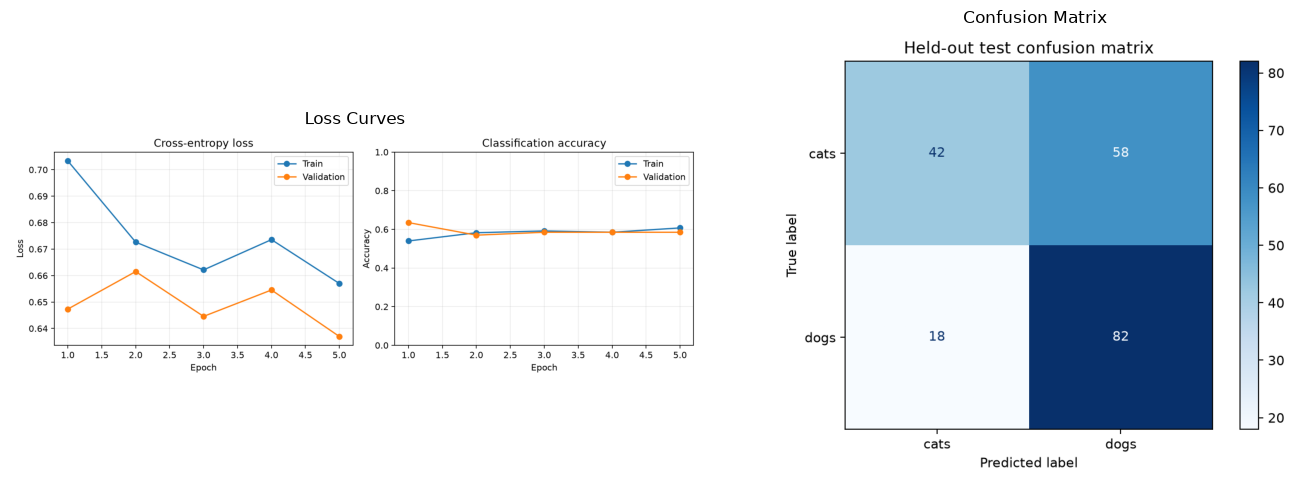

In [14]:
metrics_path = expected_artifacts["metrics"]
if metrics_path.is_file():
    training_metrics = json.loads(metrics_path.read_text(encoding="utf-8"))
    summary_keys = (
        "test_accuracy",
        "test_precision_weighted",
        "test_recall_weighted",
        "test_f1_weighted",
        "training_duration_seconds",
        "model_version",
        "model_sha256",
        "mlflow_run_id",
        "device",
        "git_commit",
    )
    metric_summary = {
        key: training_metrics[key]
        for key in summary_keys
        if key in training_metrics
    }
    print(json.dumps(metric_summary, indent=2))
else:
    training_metrics = None
    print("No training metrics found; full evaluation remains pending.")

available_plot_paths = [
    expected_artifacts["learning_curves"],
    expected_artifacts["confusion_matrix"],
]
available_plot_paths = [path for path in available_plot_paths if path.is_file()]

if available_plot_paths:
    figure, axes = plt.subplots(1, len(available_plot_paths), figsize=(7 * len(available_plot_paths), 5))
    axes = np.atleast_1d(axes)
    for axis, plot_path in zip(axes, available_plot_paths):
        with Image.open(plot_path) as plot_image:
            axis.imshow(plot_image)
        axis.set_title(plot_path.stem.replace("_", " ").title())
        axis.axis("off")
    figure.tight_layout()
    plt.show()
else:
    print("No diagnostic plots found; run the tracked training stage to generate them.")

## 11. Observations and interpretation

Complete this section **after the full run** by referring to the displayed JSON and plots.
Replace bracketed fields with observed values; do not estimate them.

- **Data:** `[N]` processed images; train/validation/test counts were `[COUNTS]`. The manifest
  audit found `[0/OTHER]` cross-split source duplicates and `[0/OTHER]` cross-split content
  duplicates.
- **Optimization:** training loss `[DECREASED/DID NOT DECREASE]`; the train–validation gap at
  the final epoch was `[VALUE]`, suggesting `[INTERPRETATION]`.
- **Held-out test:** accuracy was `[VALUE]`; weighted precision/recall/$F_1$ were
  `[VALUES]`.
- **Error pattern:** the confusion matrix shows `[OBSERVED CLASS-SPECIFIC PATTERN]`.
- **Traceability:** MLflow run ID `[RUN ID]` produced model SHA-256 `[CHECKSUM]` from Git
  revision `[COMMIT]`.

### Dry-run observation

When training is disabled, a successful execution establishes only that imports,
configuration, preprocessing, tensor normalization, CNN construction, and output dimensions
are internally consistent. It does **not** establish predictive performance.

## 12. Conclusion

This notebook connects the academic CNN workflow to a production-oriented MLOps contract.
Data origin and split assignment are auditable, the preprocessing path is shared with
serving, the model's input/output interface is asserted, and the canonical training command
records metrics and versioned artifacts through MLflow. After executing the full run and
replacing the observation placeholders with measured values, the notebook provides a
reproducible evidence trail from dataset configuration to deployment checkpoint.

## 13. Limitations and possible improvements

1. **Baseline capacity:** the small CNN is transparent and inexpensive, but a pretrained
   MobileNet/EfficientNet backbone could improve data efficiency. Compare it through a
   tracked experiment rather than replacing the baseline without evidence.
2. **Dataset scope:** a public cats/dogs dataset may contain background, breed, camera, and
   annotation biases. Evaluate external and user-uploaded images before production use.
3. **Binary closed set:** softmax always selects cats or dogs, even for unrelated or
   low-quality images. Add out-of-distribution detection or an abstention threshold.
4. **Evaluation depth:** weighted aggregate metrics can hide per-class weakness. Add a
   classification report, confidence calibration, ROC/PR curves, and slice-based analysis.
5. **Experiment breadth:** the current configuration is one baseline, not a hyperparameter
   study. Track controlled comparisons for learning rate, augmentation, architecture, and
   class-balanced sampling.
6. **Reproducibility boundary:** fixed seeds improve repeatability but do not guarantee
   identical GPU results across drivers and hardware. Preserve the container digest and
   dependency lock alongside the run.
7. **Monitoring:** offline accuracy does not detect production drift. Use API telemetry and
   user feedback to monitor confidence, latency, error rate, and delayed correctness.

### Exact commands for the final evidence run

```powershell
.\.venv\Scripts\Activate.ps1
dvc repro
jupyter nbconvert --execute --to notebook --inplace notebooks\01_model_development.ipynb
mlflow ui --backend-store-uri file:./mlruns --port 5000
```

Before the final notebook execution, set `RUN_TRAINING = False` if `dvc repro` has already
generated the canonical five-epoch artifacts; the notebook will then inspect those artifacts
without launching a duplicate training run.